=== СТРУКТУРА ДАННЫХ ===
Столбцы метаданных: ['DATASET', 'SERIES_CODE', 'OBS_MEASURE', 'COUNTRY', 'INDICATOR', 'FREQUENCY', 'SCALE']
Диапазон лет: 1979 - 2031 (53 лет)

=== ПОСЛЕ ТРАНСФОРМАЦИИ ===
Размерность: (6784, 9)

=== ДОСТУПНОСТЬ ДАННЫХ ===
Наблюдений с Gross debt: 954
Наблюдений с Net lending/borrowing: 1908

=== РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ===
GROUP
Low-Income Developing    428
Emerging Markets         420
Advanced Economies       155
G7/G20                   142
Oil Producers             82
World                     74
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_8844\272564115.py:257: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_8844\272564115.py:258: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.savefig('phase_portraits_analysis.png', dpi=300, bbox_inches='tight')
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


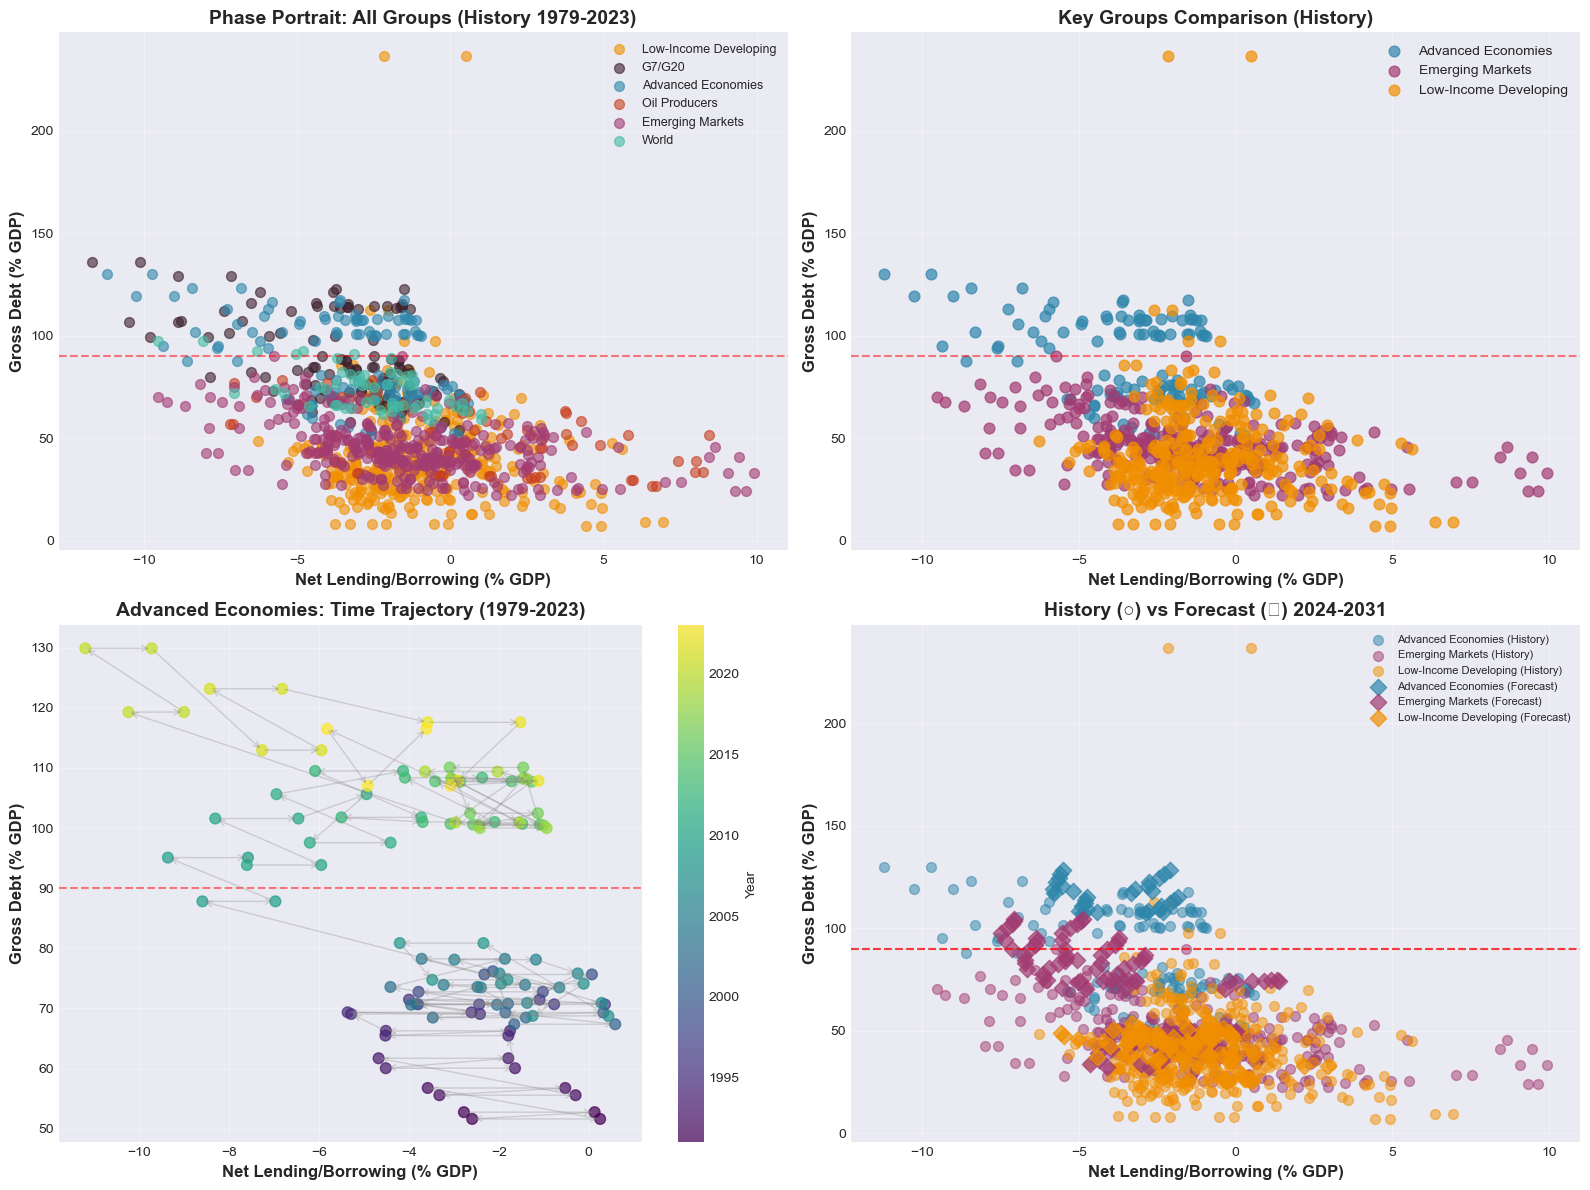


 АНАЛИЗ ЗАВЕРШЕН
 График сохранен: phase_portraits_analysis.png
 Размерность данных: 1301 наблюдений
 Диапазон лет: 1990 - 2031
 Групп стран: 6


In [14]:

# ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ПАЙПЛАЙН
# Фазовые портреты фискальной динамики: Долг vs Дефицит

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'dataset_2026-09-30T18_12_48_858129640Z_DEFAULT_INTEGRATION_IMF_FAD_FM_5_0_0.csv'
df_wide = pd.read_csv(file_path)

# Антихрупкое разделение метаданных и временных рядов
id_cols = [c for c in df_wide.columns if not c.isdigit()]
year_cols = [c for c in df_wide.columns if c.isdigit()]

print(f"=== СТРУКТУРА ДАННЫХ ===")
print(f"Столбцы метаданных: {id_cols}")
print(f"Диапазон лет: {min(year_cols)} - {max(year_cols)} ({len(year_cols)} лет)")


df_long = df_wide.melt(
    id_vars=id_cols, 
    value_vars=year_cols, 
    var_name='YEAR', 
    value_name='VALUE'
)

df_long['YEAR'] = df_long['YEAR'].astype(int)

print(f"\n=== ПОСЛЕ ТРАНСФОРМАЦИИ ===")
print(f"Размерность: {df_long.shape}")


# Gross debt (государственный долг)
debt_mask = df_long['INDICATOR'].str.contains('Gross debt', case=False, na=False)
df_debt = df_long[debt_mask][['COUNTRY', 'YEAR', 'VALUE']].copy()
df_debt.rename(columns={'VALUE': 'GROSS_DEBT'}, inplace=True)

# Net lending/borrowing (фискальный баланс/дефицит)
balance_mask = df_long['INDICATOR'].str.contains('Net lending.*net borrowing', case=False, na=False)
df_balance = df_long[balance_mask][['COUNTRY', 'YEAR', 'VALUE']].copy()
df_balance.rename(columns={'VALUE': 'NET_LENDING'}, inplace=True)

print(f"\n=== ДОСТУПНОСТЬ ДАННЫХ ===")
print(f"Наблюдений с Gross debt: {len(df_debt)}")
print(f"Наблюдений с Net lending/borrowing: {len(df_balance)}")

ax4 = axes[1, 1]

# История (круги)
history_key = history_data[history_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = history_key[history_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (History)',
        alpha=0.5,
        s=50,
        marker='o'
    )

# Прогноз (ромбы вместо треугольников — совместимо с Arial)
forecast_data = df_phase[df_phase['IS_FORECAST']]
forecast_key = forecast_data[forecast_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = forecast_key[forecast_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (Forecast)',
        alpha=0.7,
        s=70,
        marker='D'  # ← ИЗМЕНЕНО: 'D' (ромб) вместо '^' (треугольник)
    )

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (◆) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

def classify_country(country):
    """Классификация стран по группам МВФ"""
    if 'Advanced' in country:
        return 'Advanced Economies'
    elif 'Emerging' in country or 'Middle-Income' in country:
        return 'Emerging Markets'
    elif 'Low-Income' in country:
        return 'Low-Income Developing'
    elif 'Oil Producers' in country:
        return 'Oil Producers'
    elif 'G7' in country or 'G20' in country:
        return 'G7/G20'
    elif 'World' in country:
        return 'World'
    else:
        return 'Other'

df_phase['GROUP'] = df_phase['COUNTRY'].apply(classify_country)

# Разделение на историю и прогноз (граница 2023)
df_phase['IS_FORECAST'] = df_phase['YEAR'] > 2023

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ===")
print(df_phase['GROUP'].value_counts())


# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Цветовая палитра
palette = {
    'Advanced Economies': '#2E86AB',
    'Emerging Markets': '#A23B72',
    'Low-Income Developing': '#F18F01',
    'Oil Producers': '#C73E1D',
    'G7/G20': '#3B1F2B',
    'World': '#44BBA4',
    'Other': 'gray'
}

# Ключевые группы для сравнения
key_groups = ['Advanced Economies', 'Emerging Markets', 'Low-Income Developing']
history_data = df_phase[~df_phase['IS_FORECAST']]

ax1 = axes[0, 0]

for group in history_data['GROUP'].unique():
    group_data = history_data[history_data['GROUP'] == group]
    ax1.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=group,
        alpha=0.6,
        s=50
    )

ax1.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax1.set_title('Phase Portrait: All Groups (History 1979-2023)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='Critical threshold (90%)')
ax1.grid(True, alpha=0.3)


ax2 = axes[0, 1]
key_data = history_data[history_data['GROUP'].isin(key_groups)]

for group in key_groups:
    group_data = key_data[key_data['GROUP'] == group]
    ax2.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=group,
        alpha=0.7,
        s=60
    )

ax2.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax2.set_title('Key Groups Comparison (History)', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)


ax3 = axes[1, 0]
advanced_data = history_data[history_data['GROUP'] == 'Advanced Economies'].sort_values('YEAR')

# Scatter с цветовым градиентом по времени
scatter = ax3.scatter(
    advanced_data['NET_LENDING'], 
    advanced_data['GROSS_DEBT'], 
    c=advanced_data['YEAR'], 
    cmap='viridis',
    alpha=0.7,
    s=60
)

# Стрелки для показа направления
for i in range(len(advanced_data) - 1):
    ax3.annotate(
        '', 
        xy=(advanced_data.iloc[i+1]['NET_LENDING'], advanced_data.iloc[i+1]['GROSS_DEBT']),
        xytext=(advanced_data.iloc[i]['NET_LENDING'], advanced_data.iloc[i]['GROSS_DEBT']),
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.3)
    )

ax3.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax3.set_title('Advanced Economies: Time Trajectory (1979-2023)', fontsize=14, fontweight='bold')
ax3.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Year', fontsize=10)


ax4 = axes[1, 1]

ax4 = axes[1, 1]

# История (круги)
history_key = history_data[history_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = history_key[history_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (History)',
        alpha=0.5,
        s=50,
        marker='o'
    )

# Прогноз (ромбы вместо треугольников — совместимо с Arial)
forecast_data = df_phase[df_phase['IS_FORECAST']]
forecast_key = forecast_data[forecast_data['GROUP'].isin(key_groups)]
for group in key_groups:
    group_data = forecast_key[forecast_key['GROUP'] == group]
    ax4.scatter(
        group_data['NET_LENDING'], 
        group_data['GROSS_DEBT'], 
        c=palette.get(group, 'gray'),
        label=f'{group} (Forecast)',
        alpha=0.7,
        s=70,
        marker='D'  # ← ИЗМЕНЕНО: 'D' (ромб) вместо '^' (треугольник)
    )

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (◆) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

ax4.set_xlabel('Net Lending/Borrowing (% GDP)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Gross Debt (% GDP)', fontsize=12, fontweight='bold')
ax4.set_title('History (○) vs Forecast (△) 2024-2031', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)



plt.tight_layout()
plt.savefig('phase_portraits_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print(" АНАЛИЗ ЗАВЕРШЕН")
print("="*70)
print(f" График сохранен: phase_portraits_analysis.png")
print(f" Размерность данных: {df_phase.shape[0]} наблюдений")
print(f" Диапазон лет: {df_phase['YEAR'].min()} - {df_phase['YEAR'].max()}")
print(f" Групп стран: {df_phase['GROUP'].nunique()}")
print("="*70)

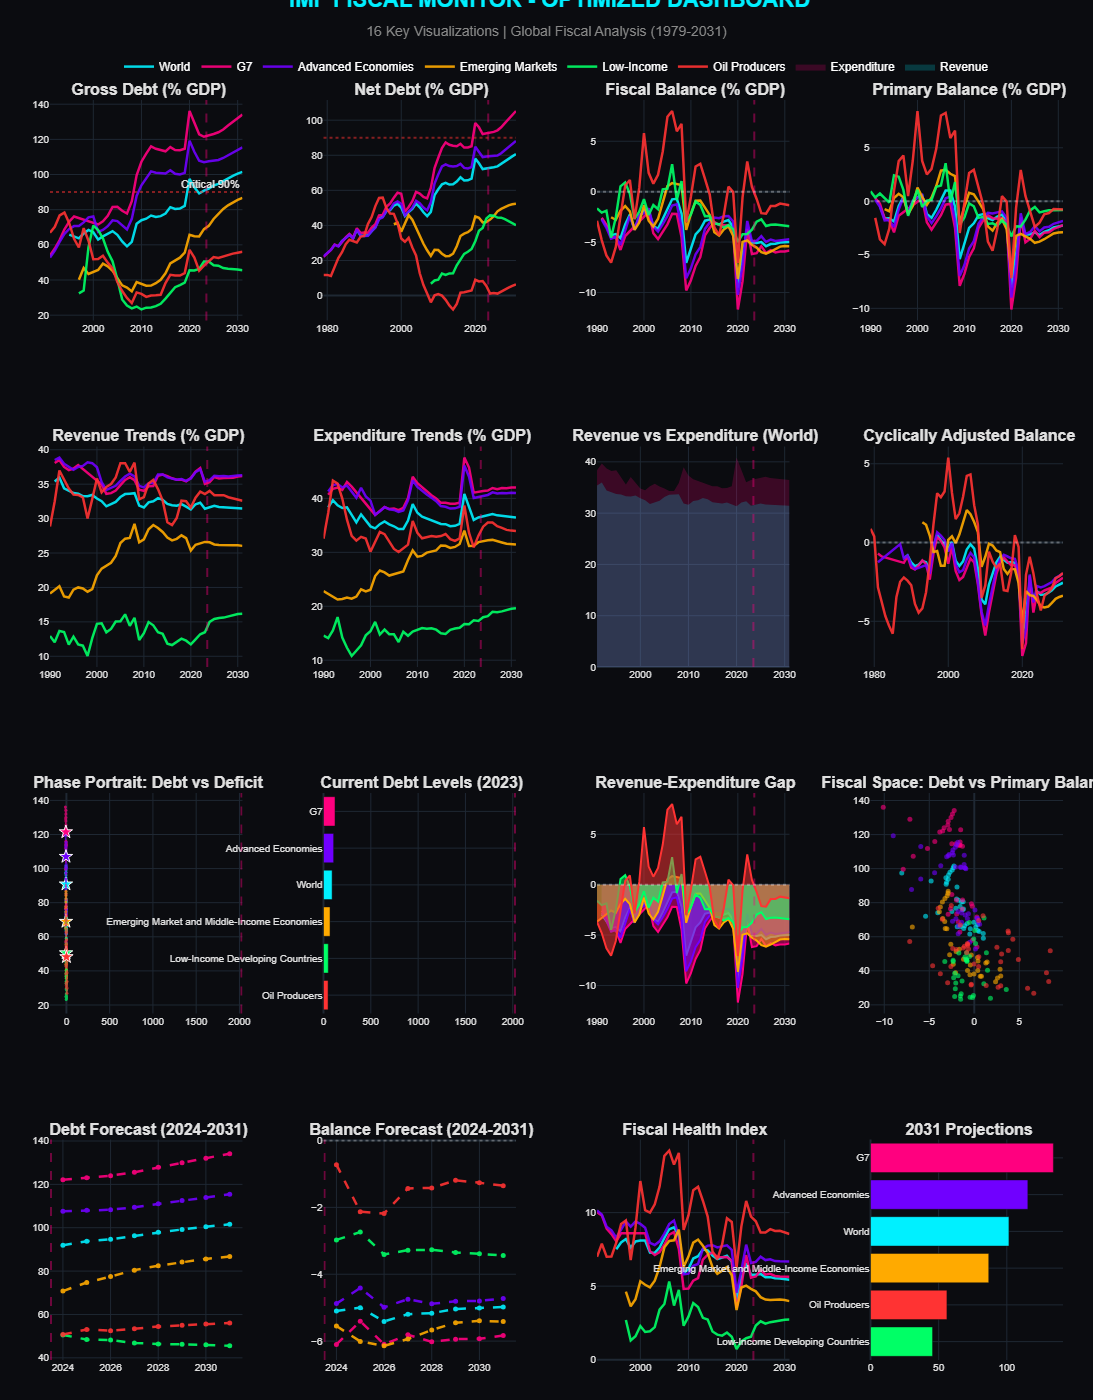

 OPTIMIZED DASHBOARD CREATED
 Total visualizations: 16 (removed 8 uninformative)
 Time period: 1979-2031
 Country groups: 6
 Focus: Key metrics, structure, analytics, forecasts


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Загрузка и подготовка данных
file_path = 'dataset_2026-09-30T18_12_48_858129640Z_DEFAULT_INTEGRATION_IMF_FAD_FM_5_0_0.csv'
df_wide = pd.read_csv(file_path)

id_cols = [c for c in df_wide.columns if not c.isdigit()]
year_cols = [c for c in df_wide.columns if c.isdigit()]

df_long = df_wide.melt(id_vars=id_cols, value_vars=year_cols, var_name='YEAR', value_name='VALUE')
df_long['YEAR'] = df_long['YEAR'].astype(int)
df_long = df_long.dropna(subset=['VALUE'])

target_groups = [
    'World', 'G7', 'Advanced Economies', 
    'Emerging Market and Middle-Income Economies', 
    'Low-Income Developing Countries', 'Oil Producers'
]
df_long = df_long[df_long['COUNTRY'].isin(target_groups)]

def extract_indicator(keyword, exclude_keyword=None, col_name=None):
    mask = df_long['INDICATOR'].str.contains(keyword, case=False, na=False)
    if exclude_keyword:
        mask &= ~df_long['INDICATOR'].str.contains(exclude_keyword, case=False, na=False)
    
    df_temp = df_long[mask][['COUNTRY', 'YEAR', 'VALUE']].copy()
    df_temp.rename(columns={'COUNTRY': 'GROUP'}, inplace=True)
    
    if col_name:
        df_temp.rename(columns={'VALUE': col_name}, inplace=True)
    
    return df_temp

df_debt = extract_indicator('Gross debt', col_name='GROSS_DEBT')
df_net_debt = extract_indicator('Net debt', col_name='NET_DEBT')
df_balance = extract_indicator('Net lending.*net borrowing', exclude_keyword='Primary', col_name='NET_LENDING')
df_primary_balance = extract_indicator('Primary net lending', col_name='PRIMARY_BALANCE')
df_cyclically_adjusted = extract_indicator('Cyclically adjusted primary balance', col_name='CYCLICALLY_ADJUSTED')
df_revenue = extract_indicator('Revenue', exclude_keyword='Cyclically', col_name='REVENUE')
df_expenditure = extract_indicator('Expenditure', col_name='EXPENDITURE')

group_config = {
    'World': {'name': 'World', 'color': '#00F0FF'},
    'G7': {'name': 'G7', 'color': '#FF007F'},
    'Advanced Economies': {'name': 'Advanced Economies', 'color': '#7000FF'},
    'Emerging Market and Middle-Income Economies': {'name': 'Emerging Markets', 'color': '#FFAA00'},
    'Low-Income Developing Countries': {'name': 'Low-Income', 'color': '#00FF66'},
    'Oil Producers': {'name': 'Oil Producers', 'color': '#FF3333'}
}

# Оптимизированный дашборд 4x4 = 16 информативных графиков
fig = make_subplots(
    rows=4, cols=4,
    subplot_titles=(
        # Row 1: Основные метрики
        "<b> Gross Debt (% GDP)</b>",
        "<b> Net Debt (% GDP)</b>",
        "<b> Fiscal Balance (% GDP)</b>",
        "<b> Primary Balance (% GDP)</b>",
        # Row 2: Структура бюджета
        "<b> Revenue Trends (% GDP)</b>",
        "<b> Expenditure Trends (% GDP)</b>",
        "<b> Revenue vs Expenditure (World)</b>",
        "<b> Cyclically Adjusted Balance</b>",
        # Row 3: Аналитика
        "<b> Phase Portrait: Debt vs Deficit</b>",
        "<b> Current Debt Levels (2023)</b>",
        "<b> Revenue-Expenditure Gap</b>",
        "<b> Fiscal Space: Debt vs Primary Balance</b>",
        # Row 4: Прогнозы и сравнения
        "<b> Debt Forecast (2024-2031)</b>",
        "<b> Balance Forecast (2024-2031)</b>",
        "<b> Fiscal Health Index</b>",
        "<b> 2031 Projections</b>"
    ),
    specs=[[{"secondary_y": False}]*4]*4,
    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

# === ROW 1: Основные метрики ===
for country, config in group_config.items():
    subset = df_debt[df_debt['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['GROSS_DEBT'], mode='lines', name=config['name'], line=dict(color=config['color'], width=2.5), opacity=0.9), row=1, col=1)

for country, config in group_config.items():
    subset = df_net_debt[df_net_debt['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['NET_DEBT'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=1, col=2)

for country, config in group_config.items():
    subset = df_balance[df_balance['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['NET_LENDING'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=1, col=3)

for country, config in group_config.items():
    subset = df_primary_balance[df_primary_balance['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['PRIMARY_BALANCE'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=1, col=4)

# === ROW 2: Структура бюджета ===
for country, config in group_config.items():
    subset = df_revenue[df_revenue['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['REVENUE'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=2, col=1)

for country, config in group_config.items():
    subset = df_expenditure[df_expenditure['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['EXPENDITURE'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=2, col=2)

world_rev = df_revenue[df_revenue['GROUP'] == 'World'].sort_values('YEAR')
world_exp = df_expenditure[df_expenditure['GROUP'] == 'World'].sort_values('YEAR')
fig.add_trace(go.Scatter(x=world_exp['YEAR'], y=world_exp['EXPENDITURE'], mode='lines', name='Expenditure', fill='tozeroy', line=dict(color='#FF007F', width=0), fillcolor='rgba(255, 0, 127, 0.2)'), row=2, col=3)
fig.add_trace(go.Scatter(x=world_rev['YEAR'], y=world_rev['REVENUE'], mode='lines', name='Revenue', fill='tozeroy', line=dict(color='#00F0FF', width=0), fillcolor='rgba(0, 240, 255, 0.2)'), row=2, col=3)

for country, config in group_config.items():
    subset = df_cyclically_adjusted[df_cyclically_adjusted['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['CYCLICALLY_ADJUSTED'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=2, col=4)

# === ROW 3: Аналитика ===
df_phase = pd.merge(df_debt, df_balance, on=['GROUP', 'YEAR'], how='inner')
for country, config in group_config.items():
    subset = df_phase[df_phase['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['NET_LENDING'], y=subset['GROSS_DEBT'], mode='lines+markers', name=config['name'], showlegend=False, line=dict(color=config['color'], width=1.5, dash='dot'), marker=dict(size=3, color=config['color']), opacity=0.7), row=3, col=1)
    # Точка 2023
    point_2023 = subset[subset['YEAR'] == 2023]
    if not point_2023.empty:
        fig.add_trace(go.Scatter(x=point_2023['NET_LENDING'], y=point_2023['GROSS_DEBT'], mode='markers', name=f"{config['name']} (2023)", showlegend=False, marker=dict(size=10, color=config['color'], symbol='star', line=dict(width=1, color='white'))), row=3, col=1)

debt_2023 = df_debt[df_debt['YEAR'] == 2023].sort_values('GROSS_DEBT', ascending=True)
fig.add_trace(go.Bar(x=debt_2023['GROSS_DEBT'], y=debt_2023['GROUP'], orientation='h', marker_color=[group_config[g]['color'] for g in debt_2023['GROUP']], showlegend=False), row=3, col=2)

df_gap = pd.merge(df_revenue, df_expenditure, on=['GROUP', 'YEAR'], how='inner')
df_gap['GAP'] = df_gap['REVENUE'] - df_gap['EXPENDITURE']
for country, config in group_config.items():
    subset = df_gap[df_gap['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['GAP'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2), fill='tozeroy', opacity=0.7), row=3, col=3)

df_fiscal = pd.merge(df_debt, df_primary_balance, on=['GROUP', 'YEAR'], how='inner')
for country, config in group_config.items():
    subset = df_fiscal[df_fiscal['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['PRIMARY_BALANCE'], y=subset['GROSS_DEBT'], mode='markers', name=config['name'], showlegend=False, marker=dict(size=5, color=config['color'], opacity=0.6)), row=3, col=4)

# === ROW 4: Прогнозы ===
for country, config in group_config.items():
    subset = df_debt[(df_debt['GROUP'] == country) & (df_debt['YEAR'] >= 2024)].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['GROSS_DEBT'], mode='lines+markers', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5, dash='dash'), marker=dict(size=5), opacity=0.9), row=4, col=1)

for country, config in group_config.items():
    subset = df_balance[(df_balance['GROUP'] == country) & (df_balance['YEAR'] >= 2024)].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['NET_LENDING'], mode='lines+markers', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5, dash='dash'), marker=dict(size=5), opacity=0.9), row=4, col=2)

for country, config in group_config.items():
    df_health = pd.merge(df_debt, df_balance, on=['GROUP', 'YEAR'], how='inner')
    df_health = pd.merge(df_health, df_revenue, on=['GROUP', 'YEAR'], how='inner')
    df_health['HEALTH'] = (df_health['REVENUE'] - df_health['GROSS_DEBT'] * 0.1 + df_health['NET_LENDING']) / 3
    subset = df_health[df_health['GROUP'] == country].sort_values('YEAR')
    fig.add_trace(go.Scatter(x=subset['YEAR'], y=subset['HEALTH'], mode='lines', name=config['name'], showlegend=False, line=dict(color=config['color'], width=2.5), opacity=0.9), row=4, col=3)

debt_2031 = df_debt[df_debt['YEAR'] == 2031].sort_values('GROSS_DEBT', ascending=True)
fig.add_trace(go.Bar(x=debt_2031['GROSS_DEBT'], y=debt_2031['GROUP'], orientation='h', marker_color=[group_config[g]['color'] for g in debt_2031['GROUP']], showlegend=False), row=4, col=4)

# Вертикальные линии прогноза
for row in range(1, 5):
    for col in [1, 2, 3]:
        fig.add_vline(x=2023.5, line_dash="dash", line_color="#FF007F", opacity=0.4, row=row, col=col)

# Горизонтальная линия критического порога долга
fig.add_hline(y=90, line_dash="dot", line_color="#FF3333", opacity=0.5, row=1, col=1, annotation_text="Critical 90%", annotation_position="top right")
fig.add_hline(y=90, line_dash="dot", line_color="#FF3333", opacity=0.5, row=1, col=2)

# Линия нуля для балансов
fig.add_hline(y=0, line_dash="dot", line_color="#FFFFFF", opacity=0.3, row=1, col=3)
fig.add_hline(y=0, line_dash="dot", line_color="#FFFFFF", opacity=0.3, row=1, col=4)
fig.add_hline(y=0, line_dash="dot", line_color="#FFFFFF", opacity=0.3, row=2, col=4)
fig.add_hline(y=0, line_dash="dot", line_color="#FFFFFF", opacity=0.3, row=3, col=3)
fig.add_hline(y=0, line_dash="dot", line_color="#FFFFFF", opacity=0.3, row=4, col=2)

# Макет
fig.update_layout(
    title=dict(
        text="<b> IMF FISCAL MONITOR - OPTIMIZED DASHBOARD</b><br><span style='font-size:14px; color:#888'>16 Key Visualizations | Global Fiscal Analysis (1979-2031)</span>",
        x=0.5, y=0.995, font=dict(size=22, color="#00F0FF", family="Inter, Arial")
    ),
    template='plotly_dark',
    paper_bgcolor='#0B0C10',
    plot_bgcolor='#0B0C10',
    font=dict(color='#E0E0E0', family='Inter, Arial, sans-serif', size=11),
    legend=dict(
        orientation="h", yanchor="bottom", y=1.015, xanchor="center", x=0.5,
        bgcolor='rgba(0,0,0,0)', font=dict(size=12, color='#FFFFFF')
    ),
    hoverlabel_bgcolor='#1F2833',
    hoverlabel_bordercolor='#00F0FF',
    margin=dict(l=50, r=30, t=100, b=40),
    height=1400,
    showlegend=True
)

fig.update_xaxes(gridcolor='#1F2833', zerolinecolor='#1F2833', showgrid=True, tickfont=dict(size=10))
fig.update_yaxes(gridcolor='#1F2833', zerolinecolor='#1F2833', showgrid=True, tickfont=dict(size=10))

fig.show()

print("=" * 80)
print(" OPTIMIZED DASHBOARD CREATED")
print("=" * 80)
print(f" Total visualizations: 16 (removed 8 uninformative)")
print(f" Time period: 1979-2031")
print(f" Country groups: {len(target_groups)}")
print(f" Focus: Key metrics, structure, analytics, forecasts")
print("=" * 80)